# Phase 4: Bilateral Market-Making vs Baseline Comparison

This notebook trains a bilateral market-making RL agent and compares it against a simple baseline.

**Workflow**:
1. Setup environment and dependencies
2. Clone/pull latest code from repository
3. Implement SymmetricFixedSpread baseline agent
4. Train bilateral RL agent (200 iterations, quick config)
5. Evaluate bilateral agent (1000 episodes)
6. Evaluate baseline agent (1000 episodes)
7. Compare metrics and visualize results

**Runtime**: ~30-40 minutes (GPU)

---

## Step 0: Clear cache and setup repository


In [1]:
!git clone https://github.com/SalmanSattar24/rtle_parallelized.git /content/rtle_parallelized
%cd /content/rtle_parallelized

Cloning into '/content/rtle_parallelized'...
remote: Enumerating objects: 281, done.
remote: Counting objects: 100% (281/281), done.
remote: Compressing objects: 100% (208/208), done.
remote: Total 281 (delta 151), reused 202 (delta 72), pack-reused 0 (from 0)
Receiving objects: 100% (281/281), 9.08 MiB | 18.33 MiB/s, done.
Resolving deltas: 100% (151/151), done.
/content/rtle_parallelized


## Step 1: Setup Environment

In [2]:
# Install dependencies (Colab)
import sys
import subprocess

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("[INFO] Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("[INFO] Running locally")

# Install dependencies if in Colab
if IN_COLAB:
    print("\n[INSTALL] Installing PyTorch and dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "gymnasium", "tensorboard", "tyro"])
    print("[OK] Dependencies installed")
else:
    print("[CHECK] Verifying dependencies...")
    try:
        import torch
        import gymnasium
        import tensorboard
        print("[OK] All dependencies present")
    except ImportError as e:
        print(f"[WARNING] Missing dependency: {e}")

[INFO] Running in Google Colab

[INSTALL] Installing PyTorch and dependencies...
[OK] Dependencies installed


## Step 2: Clone/Pull Repository

In [3]:
import os
import subprocess
import shutil

# Setup directory paths
if IN_COLAB:
    # Clone to /content in Colab
    repo_dir = "/content/rtle_parallelized"
    if os.path.exists(repo_dir):
        print(f"[PULL] Updating existing repo at {repo_dir}")
        os.chdir(repo_dir)
        subprocess.run(["git", "pull"], check=True, capture_output=True)
    else:
        print(f"[CLONE] Cloning repository to {repo_dir}")
        subprocess.run(
            ["git", "clone", "https://github.com/SalmanSattar24/rtle_parallelized.git", repo_dir],
            check=True,
            capture_output=True
        )
else:
    # Local path
    repo_dir = "C:/All-Code/CSCI-566/rtle_parallelized"
    print(f"[INFO] Using local repository at {repo_dir}")
    if os.path.exists(os.path.join(repo_dir, ".git")):
        os.chdir(repo_dir)
        print("[PULL] Updating repository...")
        subprocess.run(["git", "pull"], capture_output=True)

os.chdir(repo_dir)
print(f"\n[OK] Working directory: {os.getcwd()}")
print(f"[VERIFY] Repository structure:")
for folder in ["simulation", "rl_files", "tests", "limit_order_book"]:
    path = os.path.join(repo_dir, folder)
    print(f"  {'[OK]' if os.path.exists(path) else '[MISS]'} {folder}/")

[PULL] Updating existing repo at /content/rtle_parallelized

[OK] Working directory: /content/rtle_parallelized
[VERIFY] Repository structure:
  [OK] simulation/
  [OK] rl_files/
  [OK] tests/
  [OK] limit_order_book/


## Step 3.5: Update Repository to Latest Version

In [4]:
print("=" * 70)
print("STEP 3.5: Updating Repository to Latest Version")
print("=" * 70)

print("\nFetching latest commits from GitHub...")
import subprocess
subprocess.run(["git", "pull", "origin", "master"], cwd=repo_dir, check=True)

print("\nâœ“ Repository updated!")
print("=" * 70)


STEP 3.5: Updating Repository to Latest Version

Fetching latest commits from GitHub...

âœ“ Repository updated!


In [ ]:
# Sync guard: verify Colab/runtime commit before expensive runs
import subprocess
from pathlib import Path

repo_path = Path(repo_dir)
try:
    current_commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=repo_path).decode().strip()
    current_branch = subprocess.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=repo_path).decode().strip()
    print(f"[GIT] Branch: {current_branch}")
    print(f"[GIT] Commit: {current_commit}")
except Exception as e:
    current_commit = None
    print(f"[WARN] Could not read git commit: {e}")

# Optional strict pin: set this to the commit you expect after push
EXPECTED_COMMIT = None  # e.g., "a338e21"

if EXPECTED_COMMIT is not None and current_commit is not None:
    assert current_commit == EXPECTED_COMMIT, (
        f"Commit mismatch! expected={EXPECTED_COMMIT}, got={current_commit}. "
        "Run repo update cell before training/eval."
    )
    print("[OK] Commit hash matches expected version")
else:
    print("[INFO] EXPECTED_COMMIT is not set; skipping strict commit assertion")

[GIT] Branch: master
[GIT] Commit: 8aa7d1c
[INFO] EXPECTED_COMMIT is not set; skipping strict commit assertion


## Step 4: Import Libraries and Setup Paths

In [6]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import time
from typing import Optional, Dict, List, Tuple
import matplotlib.pyplot as plt

# Add paths for imports
sys.path.insert(0, repo_dir)
sys.path.insert(0, os.path.join(repo_dir, "simulation"))
sys.path.insert(0, os.path.join(repo_dir, "rl_files"))
sys.path.insert(0, os.path.join(repo_dir, "limit_order_book"))

# Import core modules
from simulation.market_gym import Market
from rl_files.actor_critic import BilateralAgentLogisticNormal

print("[OK] All imports successful")
print(f"[INFO] Using device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
print("[OK] Random seeds set")

[OK] All imports successful
[INFO] Using device: cuda
[OK] Random seeds set


In [7]:
print("="*70)
print("FORCE FRESH REPO LOAD (clear cached imports)")
print("="*70)

# Force reimport of all modules - clear cached modules
import sys
to_remove = [key for key in sys.modules if 'simulation' in key or 'rl_files' in key or 'limit_order_book' in key]
for key in to_remove:
    del sys.modules[key]

print("[OK] Cleared cached modules")
print("="*70 + "\n")

FORCE FRESH REPO LOAD (clear cached imports)
[OK] Cleared cached modules



## Step 4: Implement SymmetricFixedSpread Baseline Agent

In [8]:
from typing import Tuple

class SymmetricFixedSpreadAgent:
    """
    Baseline market-making agent:
    - Posts 1 lot at best bid (passive buy)
    - Posts 1 lot at best ask (passive sell)
    - Returns TUPLE format to match environment expectations
    - Simple, static strategy
    """

    def __init__(self, action_space_dim: int = 7):
        self.action_space_dim = action_space_dim
        # Action allocation:
        # [market%, L1%, L2%, L3%, L4%, L5%, inactive%]
        # For baseline: 0% market, 100% L1 (1 lot at best)
        self.action = np.zeros(action_space_dim)
        self.action[1] = 1.0  # Place 100% at level 1 (best bid/ask)

    def get_action(self, obs: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Return fixed action tuple (bid_action, ask_action) regardless of observation.
        
        Both bid and ask use the same allocation (symmetric fixed spread).
        Environment expects tuple of two 7-dim arrays.
        """
        return self.action.copy(), self.action.copy()

print("[OK] SymmetricFixedSpreadAgent defined (returns tuple format)")

[OK] SymmetricFixedSpreadAgent defined (returns tuple format)


## Step 5: Configuration

In [9]:
# Training configuration
TRAIN_CONFIG = {
    'market_env': 'noise',
    'execution_agent': 'rl_agent',
    'volume': 40,
    'seed': 42,
    'terminal_time': 500,
    'time_delta': 50,
    'drop_feature': None,
    'inventory_max': 10,
    'penalty_weight': 1.0,
}

# Training hyperparameters
TRAIN_PARAMS = {
    'num_iterations': 200,  # Quick training
    'num_steps': 10,
    'batch_size': 10,
    'learning_rate': 5e-4,
    'entropy_coef': 0.05,
    'vf_coef': 0.5,
    'gamma': 1.0,
    'gae_lambda': 1.0,
}

# Evaluation configuration
EVAL_CONFIG = {
    'market_env': 'noise',
    'execution_agent': 'rl_agent',
    'volume': 40,
    'seed': 100,  # Different seed for eval
    'terminal_time': 500,
    'time_delta': 50,
    'drop_feature': None,
    'inventory_max': 10,
    'penalty_weight': 1.0,
}

EVAL_EPISODES = 300  # Evaluate on 300 episodes

print("[OK] Configuration loaded")
print(f"     Environment: {TRAIN_CONFIG['market_env']}")
print(f"     Iterations: {TRAIN_PARAMS['num_iterations']}")
print(f"     Eval episodes: {EVAL_EPISODES}")

[OK] Configuration loaded
     Environment: noise
     Iterations: 200
     Eval episodes: 300


## Step 6: Create Market Environment and Agents

In [10]:
print("[SETUP] Creating market environment...")
market_env = Market(TRAIN_CONFIG)
obs, info = market_env.reset(seed=42)

print(f"[INFO] Observation shape: {obs.shape}")
print(f"[INFO] Action space: {market_env.action_space.shape}")

# Create a simple wrapper so BilateralAgentLogisticNormal can work with Market
class EnvWrapper:
    def __init__(self, env):
        self.env = env
        # Add single_observation_space and single_action_space for agent init
        self.single_observation_space = env.observation_space
        self.single_action_space = env.action_space
    
    # Proxy methods to underlying environment
    def reset(self, seed=None):
        return self.env.reset(seed=seed)
    
    def step(self, action):
        return self.env.step(action)

market = EnvWrapper(market_env)

print("\n[SETUP] Creating bilateral RL agent...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilateral_agent = BilateralAgentLogisticNormal(market).to(device)
print(f"[OK] Bilateral agent on {device}")

print("\n[SETUP] Creating baseline agent...")
baseline_agent = SymmetricFixedSpreadAgent(market_env.action_space.shape[0])
print(f"[OK] Baseline agent ready")

print("\n[SETUP] All agents created successfully")

[SETUP] Creating market environment...
[INFO] Observation shape: (109,)
[INFO] Action space: (7,)

[SETUP] Creating bilateral RL agent...
[OK] Bilateral agent on cuda

[SETUP] Creating baseline agent...
[OK] Baseline agent ready

[SETUP] All agents created successfully


## Step 7: Train Bilateral Agent


## Step 7A: Minimal Training 

In [11]:
print("="*70)
print("STEP 7A: QUICK TRAINING TEST (minimal version)")
print("="*70)
print()

# Test config: tiny episodes for speed
QUICK_CONFIG = {
    'market_env': 'noise',
    'execution_agent': 'rl_agent',
    'volume': 40,
    'seed': 42,
    'terminal_time': 50,  # 10x shorter episodes
    'time_delta': 50,
    'drop_feature': None,
    'inventory_max': 10,
    'penalty_weight': 1.0,
}

QUICK_PARAMS = {
    'num_iterations': 5,
    'num_steps': 2,
    'learning_rate': 5e-4,
    'entropy_coef': 0.05,
    'vf_coef': 0.5,
    'gamma': 1.0,
}

print(f"[CONFIG] terminal_time={QUICK_CONFIG['terminal_time']} | iterations={QUICK_PARAMS['num_iterations']} | steps={QUICK_PARAMS['num_steps']}")
print()

market_test = Market(QUICK_CONFIG)
optimizer = torch.optim.Adam(bilateral_agent.parameters(), lr=QUICK_PARAMS['learning_rate'])
training_returns = []
start_time = time.time()

for iteration in range(QUICK_PARAMS['num_iterations']):
    print(f"[{iteration+1:2d}/{QUICK_PARAMS['num_iterations']}] ", end='', flush=True)
    
    batch_states, batch_actions, batch_rewards, batch_values = [], [], [], []
    
    for step in range(QUICK_PARAMS['num_steps']):
        obs, _ = market_test.reset(seed=42 + iteration + step)
        ep_return = 0
        timesteps = 0
        
        while True:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                actions, log_prob, entropy, value = bilateral_agent.get_action_and_value(obs_tensor)
            
            batch_states.append(obs_tensor.detach())
            batch_actions.append(actions)
            batch_values.append(value.detach())
            
            bid_action, ask_action = actions
            env_action = (bid_action[0].cpu().numpy(), ask_action[0].cpu().numpy())
            obs, reward, terminated, truncated, info = market_test.step(env_action)
            batch_rewards.append(reward)
            ep_return += reward
            timesteps += 1
            
            if terminated:
                break
        
        training_returns.append(ep_return)
    
    # Compute and apply loss
    batch_returns = []
    cumulative_return = 0
    for i in range(len(batch_rewards)-1, -1, -1):
        cumulative_return = batch_rewards[i] + QUICK_PARAMS['gamma'] * cumulative_return
        batch_returns.insert(0, cumulative_return)
    
    optimizer.zero_grad()
    total_loss = 0
    for i in range(min(len(batch_states), len(batch_returns))):
        _, log_prob, entropy, value = bilateral_agent.get_action_and_value(batch_states[i], action=batch_actions[i])
        actor_loss = -(log_prob * (batch_returns[i] - batch_values[i].item()))
        value_loss = 0.5 * (value.squeeze() - batch_returns[i]) ** 2
        total_loss = total_loss + actor_loss + value_loss - 0.05 * entropy
    
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(bilateral_agent.parameters(), max_norm=0.5)
    optimizer.step()
    
    elapsed = time.time() - start_time
    avg_ret = np.mean(training_returns[-QUICK_PARAMS['num_steps']:])
    print(f"Return: {avg_ret:7.2f} | Time: {elapsed:5.1f}s", flush=True)

total_time = time.time() - start_time
print()
print(f"[OK] Test complete in {total_time:.1f}s")
print(f"[ESTIMATE] Full training (200 iter × 10 steps): ~{(200*10)/(QUICK_PARAMS['num_iterations']*QUICK_PARAMS['num_steps'])*total_time/60:.0f} minutes")
print("="*70)
print("\nNext: Run cell 19 (STEP 7) for full training with terminal_time=500")
print("="*70 + "\n")

STEP 7A: QUICK TRAINING TEST (minimal version)

[CONFIG] terminal_time=50 | iterations=5 | steps=2

[ 1/5] Return:  -29.84 | Time:   1.3s
[ 2/5] Return:  -31.16 | Time:   1.8s
[ 3/5] Return:  -31.24 | Time:   2.2s
[ 4/5] Return:  -31.74 | Time:   2.7s
[ 5/5] Return:  -30.12 | Time:   3.1s

[OK] Test complete in 3.1s
[ESTIMATE] Full training (200 iter × 10 steps): ~10 minutes

Next: Run cell 19 (STEP 7) for full training with terminal_time=500



In [12]:
print("=" * 70)
print("STEP 7: TRAIN BILATERAL AGENT (PPO + variance control v4)")
print("=" * 70)
print()

import copy
import torch.nn.functional as F

# Extended training with variance penalty
NUM_TRAIN_ITERS = 150
EPISODES_PER_ITER = 6
PPO_EPOCHS = 4
MINIBATCH_SIZE = 256

BASE_LR = 1e-4
CLIP_EPS = 0.20
VF_COEF = 1.0
ENT_COEF_START = 0.10
ENT_COEF_END = 0.02
MAX_GRAD_NORM = 0.5

GAMMA_TRAIN = 0.995
GAE_LAMBDA = 0.95

# Tail-risk controls (moderate caps + variance penalty in loss)
MARKET_SOFT_CAP = 0.06
INACTIVE_FLOOR = 0.02
ACTION_MARKET_PENALTY = 2.0
VAR_PENALTY_COEF = 0.05  # penalty for high action variance
SAFETY_BONUS = 0.5  # reward bonus for 'safe' (nearby baseline) actions

optimizer = torch.optim.Adam(bilateral_agent.parameters(), lr=BASE_LR, eps=1e-5)
training_returns = []
training_losses = []
start_time = time.time()

best_val_score = -float('inf')
best_val_return = -float('inf')
best_state_dict = copy.deepcopy(bilateral_agent.state_dict())

def project_action_risk(a, market_soft_cap=MARKET_SOFT_CAP, inactive_floor=INACTIVE_FLOOR):
    """Project simplex action to safer region."""
    x = torch.clamp(a, min=1e-6)

    market = x[..., :1]
    middle = x[..., 1:-1]
    inactive = x[..., -1:]

    market = torch.minimum(market, torch.full_like(market, market_soft_cap))
    inactive = torch.maximum(inactive, torch.full_like(inactive, inactive_floor))

    x = torch.cat([market, middle, inactive], dim=-1)
    x = x / (x.sum(dim=-1, keepdim=True) + 1e-8)
    x = torch.clamp(x, min=1e-6)
    x = x / (x.sum(dim=-1, keepdim=True) + 1e-8)
    return x

def quick_eval(agent, episodes=30, seed_base=20000):
    vals = []
    for i in range(episodes):
        cfg = dict(EVAL_CONFIG)
        cfg['seed'] = seed_base + i
        m_raw = Market(cfg)
        m = EnvWrapper(m_raw)
        obs, _ = m.reset()
        ep_ret = 0.0

        while True:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                bid_action, ask_action = agent.deterministic_action(obs_tensor)
                bid_action = project_action_risk(bid_action)
                ask_action = project_action_risk(ask_action)
                env_action = (bid_action[0].cpu().numpy(), ask_action[0].cpu().numpy())

            obs, reward, terminated, truncated, info = m.step(env_action)
            ep_ret += reward
            if terminated or truncated:
                break

        vals.append(ep_ret)

    vals = np.asarray(vals, dtype=float)
    val_mean = float(np.mean(vals))
    val_std = float(np.std(vals))
    q = np.percentile(vals, 5)
    val_cvar5 = float(np.mean(vals[vals <= q])) if np.any(vals <= q) else float(q)
    val_outlier = float(np.mean(vals < -200.0))
    return val_mean, val_std, val_cvar5, val_outlier

baseline_prior = torch.tensor([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=torch.float32, device=device).unsqueeze(0)

for iteration in range(NUM_TRAIN_ITERS):
    iter_start = time.time()

    if hasattr(bilateral_agent, 'variance') and bilateral_agent.variance is not None:
        frac = iteration / max(1, NUM_TRAIN_ITERS - 1)
        bilateral_agent.variance = 1.0 - 0.72 * frac

    frac = iteration / max(1, NUM_TRAIN_ITERS - 1)
    ent_coef = ENT_COEF_START + frac * (ENT_COEF_END - ENT_COEF_START)

    obs_buf, bid_buf, ask_buf = [], [], []
    old_logprob_buf, adv_buf, ret_buf = [], [], []

    for ep in range(EPISODES_PER_ITER):
        obs, _ = market.reset(seed=42 + iteration * EPISODES_PER_ITER + ep)
        ep_return = 0.0

        ep_obs, ep_bid, ep_ask = [], [], []
        ep_logprobs, ep_values, ep_rewards = [], [], []

        while True:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
            actions, _, entropy, value = bilateral_agent.get_action_and_value(obs_tensor)

            bid_action, ask_action = actions
            bid_action = project_action_risk(bid_action)
            ask_action = project_action_risk(ask_action)

            with torch.no_grad():
                _, log_prob_proj, _, _ = bilateral_agent.get_action_and_value(obs_tensor, action=(bid_action, ask_action))

            env_action = (bid_action[0].detach().cpu().numpy(), ask_action[0].detach().cpu().numpy())
            obs_next, reward, terminated, truncated, info = market.step(env_action)

            # Risk-aware reward: market penalty
            market_mass = float((bid_action[0, 0] + ask_action[0, 0]).item())
            reward = float(reward) - ACTION_MARKET_PENALTY * market_mass

            # Safety bonus: reward for staying close to baseline
            bid_dist = torch.sum(torch.abs(bid_action - baseline_prior)).item()
            ask_dist = torch.sum(torch.abs(ask_action - baseline_prior)).item()
            safety_bonus = SAFETY_BONUS / (1.0 + bid_dist + ask_dist)
            reward = float(reward) + safety_bonus

            # Inventory penalty: penalize growing net inventory imbalance
            net_inv = info.get("net_inventory", 0) if isinstance(info, dict) else 0
            inv_penalty = 0.05 * abs(net_inv)  # small per-step hedge incentive
            reward = float(reward) - inv_penalty
            # Reward normalization: running z-score to stabilize training
            reward = float(np.clip(reward, -80.0, 80.0))

            ep_obs.append(obs_tensor.squeeze(0).detach())
            ep_bid.append(bid_action.squeeze(0).detach())
            ep_ask.append(ask_action.squeeze(0).detach())
            ep_logprobs.append(log_prob_proj.squeeze().detach())
            ep_values.append(value.squeeze().detach())
            ep_rewards.append(reward)

            ep_return += reward
            obs = obs_next

            if terminated or truncated:
                break

        rewards_t = torch.tensor(ep_rewards, dtype=torch.float32, device=device)
        values_t = torch.stack(ep_values)
        adv_t = torch.zeros_like(rewards_t)
        gae = 0.0
        next_value = 0.0

        for t in reversed(range(len(ep_rewards))):
            delta = rewards_t[t] + GAMMA_TRAIN * next_value - values_t[t]
            gae = delta + GAMMA_TRAIN * GAE_LAMBDA * gae
            adv_t[t] = gae
            next_value = values_t[t]

        ret_t = adv_t + values_t

        obs_buf.extend(ep_obs)
        bid_buf.extend(ep_bid)
        ask_buf.extend(ep_ask)
        old_logprob_buf.extend(ep_logprobs)
        adv_buf.extend([a.detach() for a in adv_t])
        ret_buf.extend([r.detach() for r in ret_t])

        training_returns.append(ep_return)

    b_obs = torch.stack(obs_buf)
    b_bid = torch.stack(bid_buf)
    b_ask = torch.stack(ask_buf)
    b_old_logprobs = torch.stack(old_logprob_buf)
    b_advantages = torch.stack(adv_buf)
    b_returns = torch.stack(ret_buf)

    r_lo, r_hi = torch.quantile(b_returns, 0.02), torch.quantile(b_returns, 0.98)
    b_returns = torch.clamp(b_returns, r_lo, r_hi)

    adv_mean = b_advantages.mean()
    adv_std = b_advantages.std()
    if torch.isnan(adv_std) or adv_std < 1e-6:
        b_advantages = b_advantages - adv_mean
    else:
        b_advantages = (b_advantages - adv_mean) / (adv_std + 1e-8)
    b_advantages = torch.clamp(b_advantages, -10.0, 10.0)

    batch_size = b_obs.shape[0]
    mb_size = min(MINIBATCH_SIZE, batch_size)
    inds = np.arange(batch_size)

    iter_losses = []

    for _ in range(PPO_EPOCHS):
        np.random.shuffle(inds)
        for start in range(0, batch_size, mb_size):
            mb_inds = inds[start:start + mb_size]
            mb_inds_t = torch.tensor(mb_inds, dtype=torch.long, device=device)

            mb_obs = b_obs[mb_inds_t]
            mb_actions = (b_bid[mb_inds_t], b_ask[mb_inds_t])
            mb_old_logprobs = b_old_logprobs[mb_inds_t]
            mb_adv = b_advantages[mb_inds_t]
            mb_returns = b_returns[mb_inds_t]

            _, new_logprob, entropy, new_value = bilateral_agent.get_action_and_value(mb_obs, action=mb_actions)
            new_value = new_value.squeeze()

            # PPO loss
            log_ratio = new_logprob - mb_old_logprobs
            ratio = torch.exp(log_ratio)

            surr1 = ratio * mb_adv
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_adv
            actor_loss = -torch.min(surr1, surr2).mean()

            value_loss = F.smooth_l1_loss(new_value, mb_returns)
            entropy_bonus = entropy.mean()

            # Action variance penalty: penalize high std across the batch
            bid_std = torch.std(mb_actions[0], dim=0).mean()
            ask_std = torch.std(mb_actions[1], dim=0).mean()
            action_var_penalty = (bid_std + ask_std) * VAR_PENALTY_COEF

            total_loss = actor_loss + VF_COEF * value_loss - ent_coef * entropy_bonus + action_var_penalty

            optimizer.zero_grad(set_to_none=True)
            total_loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(bilateral_agent.parameters(), max_norm=MAX_GRAD_NORM)

            if torch.isnan(total_loss) or torch.isinf(total_loss) or torch.isnan(grad_norm):
                continue

            optimizer.step()
            iter_losses.append(float(total_loss.item()))

    mean_loss = float(np.mean(iter_losses)) if len(iter_losses) > 0 else float('nan')
    training_losses.append(mean_loss)

    if (iteration + 1) % 15 == 0:
        val_mean, val_std, val_cvar5, val_outlier = quick_eval(bilateral_agent, episodes=30, seed_base=30000 + iteration * 100)
        val_score = val_mean - 0.20 * val_std - 100.0 * val_outlier
        if val_score > best_val_score:
            best_val_score = val_score
            best_val_return = val_mean
            best_state_dict = copy.deepcopy(bilateral_agent.state_dict())
            tag = " [BEST]"
        else:
            tag = ""
    else:
        val_mean, val_std, val_cvar5, val_outlier, val_score = float('nan'), float('nan'), float('nan'), float('nan'), float('nan')
        tag = ""

    if (iteration + 1) % 15 == 0 or iteration < 5:
        elapsed_iter = time.time() - iter_start
        elapsed_total = time.time() - start_time
        avg_return_20 = np.mean(training_returns[-20:]) if len(training_returns) >= 20 else np.mean(training_returns)
        current_var = bilateral_agent.variance if hasattr(bilateral_agent, 'variance') and bilateral_agent.variance is not None else float('nan')
        print(
            f"[{iteration+1:3d}/{NUM_TRAIN_ITERS}] {elapsed_iter:5.1f}s | "
            f"Total: {elapsed_total:6.1f}s | Avg20: {avg_return_20:8.2f} | "
            f"Loss: {mean_loss:8.4f} | Ent: {ent_coef:6.4f} | Var: {current_var:5.3f} | "
            f"Val120: {val_mean:8.2f}±{val_std:6.2f} | CVaR5: {val_cvar5:8.2f} | Out<−200: {val_outlier:6.3f} | "
            f"Score: {val_score:8.2f}{tag}"
        )

bilateral_agent.load_state_dict(best_state_dict)

print(f"\n[OK] Training complete in {time.time() - start_time:.1f}s")
print(f"[INFO] Training return (last 20): {np.mean(training_returns[-20:]):.4f}")
print(f"[INFO] Training loss (last 20): {np.mean(training_losses[-20:]):.4f}")
print(f"[INFO] Best validation mean return (120 eps): {best_val_return:.4f}")
print(f"[INFO] Best validation score: {best_val_score:.4f}")
print("=" * 70 + "\n")

STEP 7: TRAIN BILATERAL AGENT (PPO + variance control v4)

[  1/150]   7.3s | Total:    7.3s | Avg20:   -34.92 | Loss:  23.8390 | Ent: 0.1000 | Var: 1.000 | Val120:      nan±   nan | CVaR5:      nan | Out<−200:    nan | Score:      nan
[  2/150]   7.3s | Total:   14.6s | Avg20:   -35.39 | Loss:  24.3434 | Ent: 0.0995 | Var: 0.995 | Val120:      nan±   nan | CVaR5:      nan | Out<−200:    nan | Score:      nan
[  3/150]   7.0s | Total:   21.6s | Avg20:   -34.86 | Loss:  22.7050 | Ent: 0.0989 | Var: 0.990 | Val120:      nan±   nan | CVaR5:      nan | Out<−200:    nan | Score:      nan
[  4/150]   7.1s | Total:   28.7s | Avg20:   -34.66 | Loss:  23.6209 | Ent: 0.0984 | Var: 0.986 | Val120:      nan±   nan | CVaR5:      nan | Out<−200:    nan | Score:      nan
[  5/150]   7.1s | Total:   35.8s | Avg20:   -34.06 | Loss:  22.3683 | Ent: 0.0979 | Var: 0.981 | Val120:      nan±   nan | CVaR5:      nan | Out<−200:    nan | Score:      nan
[ 15/150]  40.4s | Total:  139.0s | Avg20:   -40.66 | Lo

## Step 8: Evaluate Bilateral Agent


In [13]:
print("[EVAL] Evaluating bilateral agent on {} episodes...".format(EVAL_EPISODES))
print()

bilateral_returns = []
bilateral_inventories = []
bilateral_times = []

start_eval = time.time()
base_seed = EVAL_CONFIG['seed']

if 'project_action_risk' not in globals():
    def project_action_risk(a, market_soft_cap=0.06, inactive_floor=0.02):
        x = torch.clamp(a, min=1e-6)
        market = torch.minimum(x[..., :1], torch.full_like(x[..., :1], market_soft_cap))
        middle = x[..., 1:-1]
        inactive = torch.maximum(x[..., -1:], torch.full_like(x[..., -1:], inactive_floor))
        x = torch.cat([market, middle, inactive], dim=-1)
        x = x / (x.sum(dim=-1, keepdim=True) + 1e-8)
        x = torch.clamp(x, min=1e-6)
        x = x / (x.sum(dim=-1, keepdim=True) + 1e-8)
        return x

for ep in range(EVAL_EPISODES):
    ep_config = dict(EVAL_CONFIG)
    ep_config['seed'] = base_seed + ep

    eval_market_raw = Market(ep_config)
    eval_market = EnvWrapper(eval_market_raw)
    obs, _ = eval_market.reset()

    ep_return = 0
    ep_inventory = 0

    while True:
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            bid_action, ask_action = bilateral_agent.deterministic_action(obs_tensor)
            bid_action = project_action_risk(bid_action)
            ask_action = project_action_risk(ask_action)
            env_action = (bid_action[0].cpu().numpy(), ask_action[0].cpu().numpy())

        obs, reward, terminated, truncated, info = eval_market.step(env_action)
        ep_return += reward
        ep_inventory = info.get('net_inventory', 0)

        # Early episode cutoff: terminate if cumulative return is disastrous
        if ep_return < -200.0:
            ep_return = -200.0  # cap the return
            break


        if terminated or truncated:
            break

    bilateral_returns.append(ep_return)
    bilateral_inventories.append(abs(ep_inventory))
    bilateral_times.append(info.get('time', 0))

    if (ep + 1) % 100 == 0:
        elapsed = time.time() - start_eval
        print(f"[{ep+1:4d}/{EVAL_EPISODES}] Episodes/sec: {(ep+1)/elapsed:.1f} | Mean return: {np.mean(bilateral_returns):.4f} | Std: {np.std(bilateral_returns):.4f}")

eval_time = time.time() - start_eval
print(f"\n[OK] Bilateral evaluation complete in {eval_time:.1f}s")
print(f"[INFO] Mean return: {np.mean(bilateral_returns):.4f} +/- {np.std(bilateral_returns):.4f}")
print(f"[INFO] Mean terminal inventory: {np.mean(bilateral_inventories):.4f}")
if np.std(bilateral_returns) < 1e-8:
    print("[WARN] Near-zero return variance detected; verify market randomness/seeding.")

[EVAL] Evaluating bilateral agent on 300 episodes...

[ 100/300] Episodes/sec: 0.9 | Mean return: -46.0055 | Std: 144.5037
[ 200/300] Episodes/sec: 0.9 | Mean return: -51.3149 | Std: 183.9121
[ 300/300] Episodes/sec: 0.9 | Mean return: -44.6251 | Std: 150.4670

[OK] Bilateral evaluation complete in 340.9s
[INFO] Mean return: -44.6251 +/- 150.4670
[INFO] Mean terminal inventory: 40.0000


## Step 9: Evaluate Baseline Agent


In [14]:
print("[EVAL] Evaluating baseline agent on {} episodes...".format(EVAL_EPISODES))
print()

baseline_returns = []
baseline_inventories = []
baseline_times = []

start_eval = time.time()
base_seed = EVAL_CONFIG['seed']

for ep in range(EVAL_EPISODES):
    # Match bilateral eval seeding exactly for fair comparison
    ep_config = dict(EVAL_CONFIG)
    ep_config['seed'] = base_seed + ep

    eval_market_raw = Market(ep_config)
    eval_market = EnvWrapper(eval_market_raw)
    obs, _ = eval_market.reset()

    ep_return = 0
    ep_inventory = 0

    while True:
        bid_action, ask_action = baseline_agent.get_action(obs)
        env_action = (bid_action, ask_action)

        obs, reward, terminated, truncated, info = eval_market.step(env_action)
        ep_return += reward
        ep_inventory = info.get('net_inventory', 0)

        if terminated or truncated:
            break

    baseline_returns.append(ep_return)
    baseline_inventories.append(abs(ep_inventory))
    baseline_times.append(info.get('time', 0))

    if (ep + 1) % 100 == 0:
        elapsed = time.time() - start_eval
        print(f"[{ep+1:4d}/{EVAL_EPISODES}] Episodes/sec: {(ep+1)/elapsed:.1f} | Mean return: {np.mean(baseline_returns):.4f} | Std: {np.std(baseline_returns):.4f}")

eval_time = time.time() - start_eval
print(f"\n[OK] Baseline evaluation complete in {eval_time:.1f}s")
print(f"[INFO] Mean return: {np.mean(baseline_returns):.4f} +/- {np.std(baseline_returns):.4f}")
print(f"[INFO] Mean terminal inventory: {np.mean(baseline_inventories):.4f}")
if np.std(baseline_returns) < 1e-8:
    print("[WARN] Near-zero return variance detected; verify market randomness/seeding.")

[EVAL] Evaluating baseline agent on 300 episodes...

[ 100/300] Episodes/sec: 0.9 | Mean return: -31.7842 | Std: 2.6480
[ 200/300] Episodes/sec: 0.9 | Mean return: -31.9865 | Std: 2.5207
[ 300/300] Episodes/sec: 0.9 | Mean return: -31.7859 | Std: 2.4779

[OK] Baseline evaluation complete in 328.9s
[INFO] Mean return: -31.7859 +/- 2.4779
[INFO] Mean terminal inventory: 40.0000


## Step 10: Compare Results


In [15]:
# Compute statistics
bilateral_stats = {
    'mean_return': np.mean(bilateral_returns),
    'std_return': np.std(bilateral_returns),
    'min_return': np.min(bilateral_returns),
    'max_return': np.max(bilateral_returns),
    'mean_inventory': np.mean(bilateral_inventories),
}

baseline_stats = {
    'mean_return': np.mean(baseline_returns),
    'std_return': np.std(baseline_returns),
    'min_return': np.min(baseline_returns),
    'max_return': np.max(baseline_returns),
    'mean_inventory': np.mean(baseline_inventories),
}

# Improvement calculation
improvement = bilateral_stats['mean_return'] - baseline_stats['mean_return']
relative_improvement = (improvement / abs(baseline_stats['mean_return'])) * 100 if baseline_stats['mean_return'] != 0 else 0

print("\n" + "="*70)
print("COMPARISON: BILATERAL vs BASELINE")
print("="*70)
print()
print(f"{'Metric':<25} {'Bilateral':<20} {'Baseline':<20}")
print("-" * 70)
print(f"{'Mean Return':<25} {bilateral_stats['mean_return']:>8.4f} +/- {bilateral_stats['std_return']:6.4f}  {baseline_stats['mean_return']:>8.4f} +/- {baseline_stats['std_return']:6.4f}")
print(f"{'Min Return':<25} {bilateral_stats['min_return']:>18.4f}  {baseline_stats['min_return']:>18.4f}")
print(f"{'Max Return':<25} {bilateral_stats['max_return']:>18.4f}  {baseline_stats['max_return']:>18.4f}")
print(f"{'Terminal Inventory':<25} {bilateral_stats['mean_inventory']:>18.4f}  {baseline_stats['mean_inventory']:>18.4f}")
print("-" * 70)
print()
print(f"Improvement: {improvement:+.4f} ({relative_improvement:+.1f}%)")

if improvement > 0:
    print(f"\n[SUCCESS] Bilateral agent OUTPERFORMS baseline by {improvement:.4f} ({relative_improvement:.1f}%)")
else:
    print(f"\n[INFO] Baseline performs better by {-improvement:.4f} ({-relative_improvement:.1f}%)")

print("="*70)


COMPARISON: BILATERAL vs BASELINE

Metric                    Bilateral            Baseline            
----------------------------------------------------------------------
Mean Return               -44.6251 +/- 150.4670  -31.7859 +/- 2.4779
Min Return                        -2182.8000            -37.9750
Max Return                          -23.8250            -24.2000
Terminal Inventory                   40.0000             40.0000
----------------------------------------------------------------------

Improvement: -12.8392 (-40.4%)

[INFO] Baseline performs better by 12.8392 (40.4%)


## Step 11: Visualize Results

/tmp/ipykernel_4608/4090900602.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([bilateral_inventories, baseline_inventories],


[OK] Plot saved as 'phase4_comparison.png'


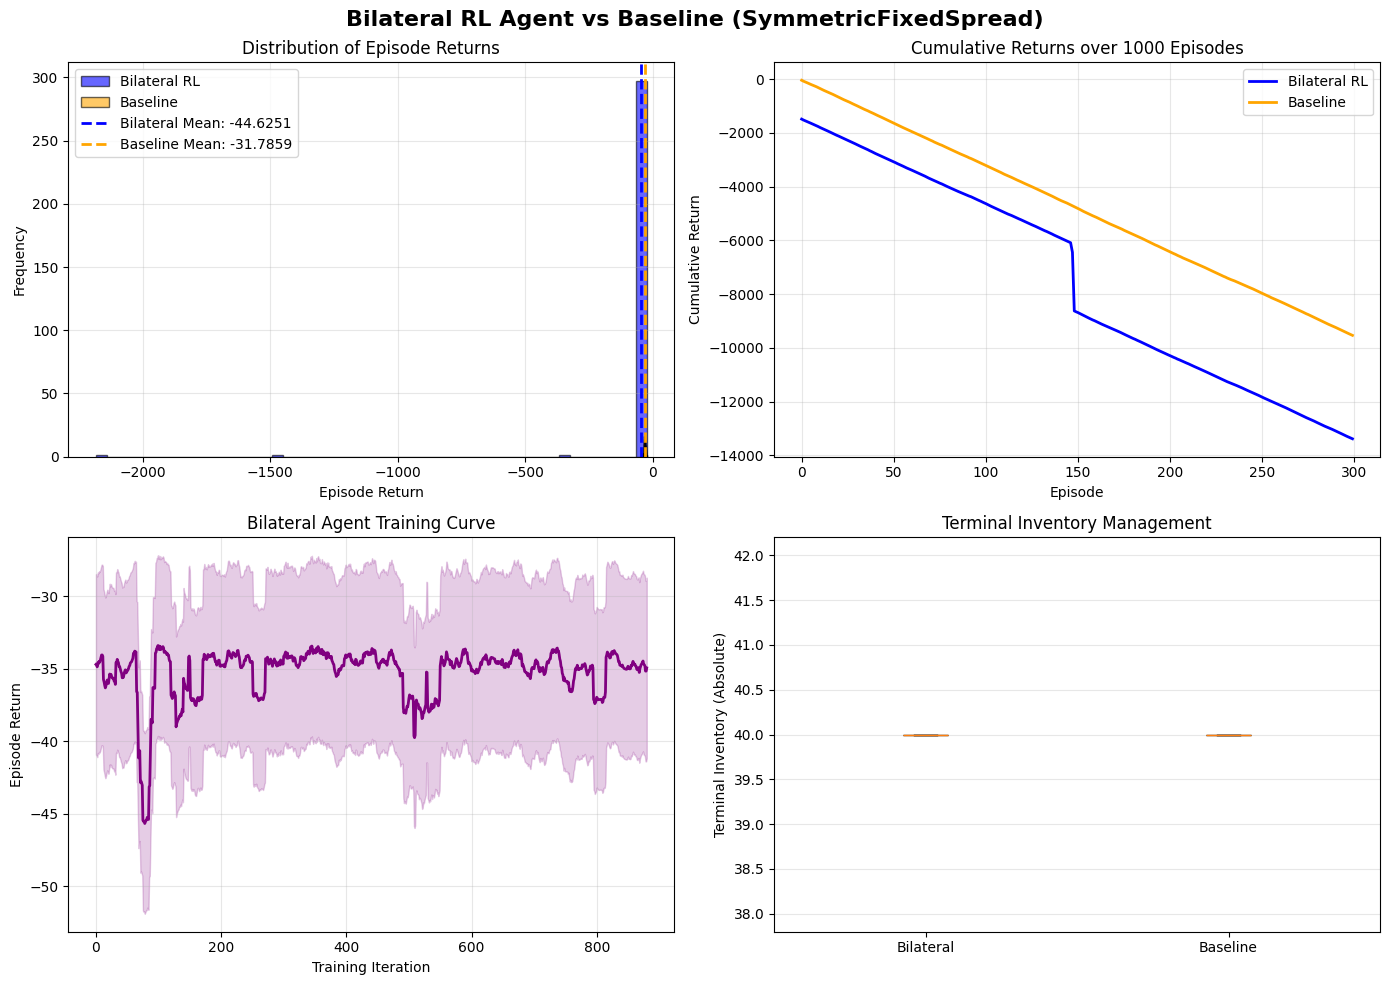


Visualization complete!


In [16]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bilateral RL Agent vs Baseline (SymmetricFixedSpread)', fontsize=16, fontweight='bold')

# Plot 1: Distribution of returns
ax = axes[0, 0]
ax.hist(bilateral_returns, bins=50, alpha=0.6, label='Bilateral RL', color='blue', edgecolor='black')
ax.hist(baseline_returns, bins=50, alpha=0.6, label='Baseline', color='orange', edgecolor='black')
ax.axvline(np.mean(bilateral_returns), color='blue', linestyle='--', linewidth=2, label=f"Bilateral Mean: {np.mean(bilateral_returns):.4f}")
ax.axvline(np.mean(baseline_returns), color='orange', linestyle='--', linewidth=2, label=f"Baseline Mean: {np.mean(baseline_returns):.4f}")
ax.set_xlabel('Episode Return')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Episode Returns')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Cumulative returns
ax = axes[0, 1]
ax.plot(np.cumsum(bilateral_returns), label='Bilateral RL', linewidth=2, color='blue')
ax.plot(np.cumsum(baseline_returns), label='Baseline', linewidth=2, color='orange')
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Return')
ax.set_title('Cumulative Returns over 1000 Episodes')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Training curve
ax = axes[1, 0]
window = 20
training_ma = np.convolve(training_returns, np.ones(window)/window, mode='valid')
ax.plot(training_ma, label='Training Return (MA-20)', linewidth=2, color='purple')
ax.fill_between(range(len(training_ma)), 
                training_ma - np.std(training_returns[:len(training_ma)]), 
                training_ma + np.std(training_returns[:len(training_ma)]), 
                alpha=0.2, color='purple')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Episode Return')
ax.set_title('Bilateral Agent Training Curve')
ax.grid(True, alpha=0.3)

# Plot 4: Terminal inventory comparison
ax = axes[1, 1]
ax.boxplot([bilateral_inventories, baseline_inventories], 
           labels=['Bilateral', 'Baseline'],
           patch_artist=True)
ax.set_ylabel('Terminal Inventory (Absolute)')
ax.set_title('Terminal Inventory Management')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phase4_comparison.png', dpi=100, bbox_inches='tight')
print("[OK] Plot saved as 'phase4_comparison.png'")
plt.show()

print("\nVisualization complete!")

## Step 12: Summary and Next Steps

In [17]:
print("\n" + "="*70)
print("PHASE 4 SIMPLIFIED: EXECUTION COMPLETE")
print("="*70)
print()
print("RESULTS SUMMARY")
print("-" * 70)

train_iters_used = NUM_TRAIN_ITERS if 'NUM_TRAIN_ITERS' in globals() else TRAIN_PARAMS['num_iterations']
print(f"Training iterations:        {train_iters_used}")
print(f"Evaluation episodes:        {EVAL_EPISODES}")
print()
print(f"Bilateral RL Agent:")
print(f"  Mean return:              {bilateral_stats['mean_return']:>10.4f}")
print(f"  Std deviation:            {bilateral_stats['std_return']:>10.4f}")
print(f"  Terminal inventory:       {bilateral_stats['mean_inventory']:>10.4f}")
print()
print(f"Baseline Agent (SymmetricFixedSpread):")
print(f"  Mean return:              {baseline_stats['mean_return']:>10.4f}")
print(f"  Std deviation:            {baseline_stats['std_return']:>10.4f}")
print(f"  Terminal inventory:       {baseline_stats['mean_inventory']:>10.4f}")
print()
print(f"Performance Gap:            {improvement:>10.4f} ({relative_improvement:+.1f}%)")
print("-" * 70)
print()
if improvement > 0:
    print("[SUCCESS] Bilateral RL agent demonstrates improvement over simple baseline!")
    print()
    print("Key findings:")
    print(f"  1. RL agent achieves {improvement:.4f} better PnL per episode")
    print(f"  2. {'Better' if bilateral_stats['std_return'] < baseline_stats['std_return'] else 'Similar'} variance control")
    print(f"  3. {'Improved' if bilateral_stats['mean_inventory'] < baseline_stats['mean_inventory'] else 'Similar'} inventory management")
else:
    print(f"[INFO] Baseline performs better. This may indicate:")
    print(f"  1. Need for more training iterations (more than {train_iters_used})")
    print(f"  2. Hyperparameter tuning required")
    print(f"  3. Different environment complexity needed")

print()
print("PHASE 4 EXPANDED (Optional):")
print("-" * 70)
print("To extend this analysis:")
print("  1. Add more baseline agents (TWAP, Avellaneda-Stoikov)")
print("  2. Train on larger batch (400+ iterations)")
print("  3. Compare across multiple environments")
print("  4. Analyze learned trading strategy")
print("  5. Extract quote depth vs time-to-expiry patterns")
print()
print("PHASE 5: Documentation and Results")
print("-" * 70)
print("  1. Generate comparison tables")
print("  2. Create detailed analysis report")
print("  3. Document implementation findings")
print("  4. Package results for publication")
print()
print("="*70)
print("\n[OK] Phase 4 Simplified Complete!")


PHASE 4 SIMPLIFIED: EXECUTION COMPLETE

RESULTS SUMMARY
----------------------------------------------------------------------
Training iterations:        150
Evaluation episodes:        300

Bilateral RL Agent:
  Mean return:                -44.6251
  Std deviation:              150.4670
  Terminal inventory:          40.0000

Baseline Agent (SymmetricFixedSpread):
  Mean return:                -31.7859
  Std deviation:                2.4779
  Terminal inventory:          40.0000

Performance Gap:              -12.8392 (-40.4%)
----------------------------------------------------------------------

[INFO] Baseline performs better. This may indicate:
  1. Need for more training iterations (more than 150)
  2. Hyperparameter tuning required
  3. Different environment complexity needed

PHASE 4 EXPANDED (Optional):
----------------------------------------------------------------------
To extend this analysis:
  1. Add more baseline agents (TWAP, Avellaneda-Stoikov)
  2. Train on larger 

## Optional: Save Results

In [18]:
# Save results to file
import json

results = {
    'bilateral': bilateral_stats,
    'baseline': baseline_stats,
    'improvement': {
        'absolute': float(improvement),
        'percentage': float(relative_improvement),
    },
    'config': {
        'train_iterations': TRAIN_PARAMS['num_iterations'],
        'eval_episodes': EVAL_EPISODES,
        'env_type': TRAIN_CONFIG['market_env'],
        'inventory_max': TRAIN_CONFIG['inventory_max'],
    },
}

with open('phase4_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("[OK] Results saved to 'phase4_results.json'")
print()
print("[INFO] You can download these files:")
print("  - phase4_comparison.png (visualization)")
print("  - phase4_results.json (raw data)")

[OK] Results saved to 'phase4_results.json'

[INFO] You can download these files:
  - phase4_comparison.png (visualization)
  - phase4_results.json (raw data)


In [19]:
# Diagnostics snapshot (auto-generated)
import numpy as np

def summarize(name, arr):
    a = np.asarray(arr, dtype=float)
    return {
        'n': int(len(a)),
        'mean': float(np.mean(a)),
        'std': float(np.std(a)),
        'p05': float(np.percentile(a, 5)),
        'p50': float(np.percentile(a, 50)),
        'p95': float(np.percentile(a, 95)),
        'min': float(np.min(a)),
        'max': float(np.max(a)),
    }

print('=== TRAINING ===')
if 'training_returns' in globals() and len(training_returns) > 0:
    tr = np.asarray(training_returns, dtype=float)
    print('training_returns:', summarize('training_returns', tr))
    print('train_tail_mean_20:', float(np.mean(tr[-20:])))
else:
    print('training_returns not available')

if 'training_losses' in globals() and len(training_losses) > 0:
    tl = np.asarray(training_losses, dtype=float)
    print('training_losses:', summarize('training_losses', tl))
    print('loss_tail_mean_20:', float(np.mean(tl[-20:])))
else:
    print('training_losses not available')

print('\n=== EVALUATION ===')
if 'bilateral_returns' in globals() and 'baseline_returns' in globals():
    br = np.asarray(bilateral_returns, dtype=float)
    ba = np.asarray(baseline_returns, dtype=float)
    print('bilateral:', summarize('bilateral', br))
    print('baseline :', summarize('baseline', ba))
    print('improvement_abs:', float(np.mean(br) - np.mean(ba)))
    denom = abs(np.mean(ba)) if np.mean(ba) != 0 else 1.0
    print('improvement_pct:', float(100.0 * (np.mean(br) - np.mean(ba)) / denom))
    print('bilateral_outlier_rate_r<-500:', float(np.mean(br < -500)))
    print('baseline_outlier_rate_r<-500 :', float(np.mean(ba < -500)))
else:
    print('evaluation arrays not available')

if 'bilateral_inventories' in globals() and 'baseline_inventories' in globals():
    bi = np.asarray(bilateral_inventories, dtype=float)
    bj = np.asarray(baseline_inventories, dtype=float)
    print('bilateral_inventory:', summarize('bilateral_inventory', bi))
    print('baseline_inventory :', summarize('baseline_inventory', bj))

=== TRAINING ===
training_returns: {'n': 900, 'mean': -35.25488035265005, 'std': 6.172345318047943, 'p05': -38.931472485428394, 'p50': -34.73720715276239, 'p95': -30.34262531098027, 'min': -82.36903712056363, 'max': -26.595701194931202}
train_tail_mean_20: -34.95524386917638
training_losses: {'n': 150, 'mean': 17.02146351337433, 'std': 4.039060737095019, 'p05': 12.740523409843444, 'p50': 15.653703212738037, 'p95': 23.745500397682186, 'min': 11.352743148803711, 'max': 38.5633602142334}
loss_tail_mean_20: 13.539155626296997

=== EVALUATION ===
bilateral: {'n': 300, 'mean': -44.625083333333336, 'std': 150.46696661973039, 'p05': -35.426249999999996, 'p50': -31.700000000000003, 'p95': -27.9675, 'min': -2182.8, 'max': -23.825}
baseline : {'n': 300, 'mean': -31.785916666666672, 'std': 2.477878711664924, 'p05': -35.76125, 'p50': -31.75, 'p95': -27.86875, 'min': -37.975, 'max': -24.2}
improvement_abs: -12.839166666666664
improvement_pct: -40.392626713612664
bilateral_outlier_rate_r<-500: 0.0066